# Step 2 — Vehicle and Road User Detection
Detect and localize vehicles, riders, and pedestrians using YOLOv8.

In [1]:
# Cell 1 — Install dependencies
!pip install ultralytics opencv-python matplotlib --quiet

In [2]:
# Cell 2 — Imports
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [ ]:
# Cell 4 — Define which COCO classes we care about
# These are the class IDs from the COCO dataset that YOLOv8 is trained on
TRAFFIC_CLASSES = {
    0:  "person",
    1:  "bicycle",
    2:  "car",
    3:  "motorcycle",
    5:  "bus",
    7:  "truck"
}

# Color for each class (R, G, B)
CLASS_COLORS = {
    "person":     (255, 165,   0),  ## orange
    "bicycle":    ( 0,  200, 100),  ## Green / Mint
    "car":        ( 0,  100, 255),  ## blue 
    "motorcycle": (255,  50,  50),  ## Red 
    "bus":        (200,   0, 200),  ## Magenta / Purple  
    "truck":      ( 50, 180,  50)   ## light green
}

print("Tracking classes:", list(TRAFFIC_CLASSES.values()))

Tracking classes: ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck']


In [6]:
# Cell 5 — Run detection on an image
# Change IMAGE_PATH to your traffic image
IMAGE_PATH = "traffic.png"

results = model.predict(
    source=IMAGE_PATH,
    conf=0.40,                              # minimum confidence
    classes=list(TRAFFIC_CLASSES.keys()),   # only detect traffic-related classes
    verbose=False
)

print(f"Detection done on: {IMAGE_PATH}")

Detection done on: traffic.png


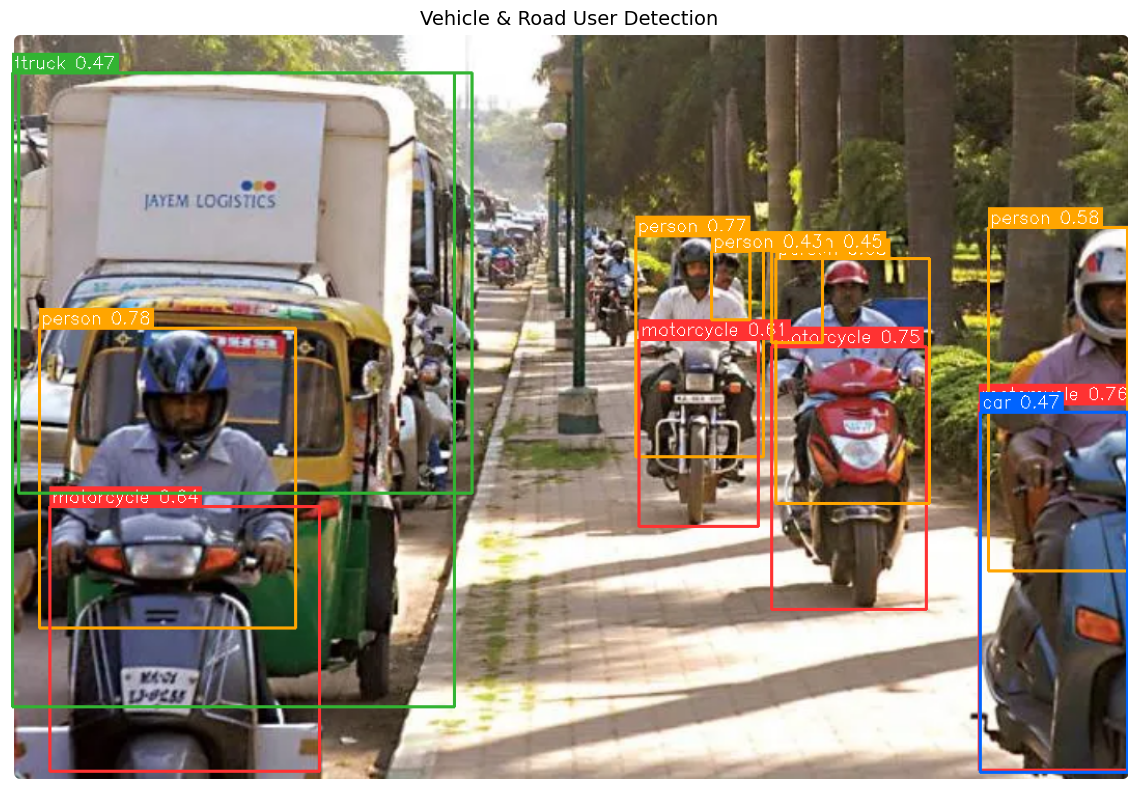

In [7]:
# Cell 6 — Draw bounding boxes and show the result
import cv2

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

boxes = results[0].boxes

for box in boxes:
    cls_id   = int(box.cls[0])
    cls_name = TRAFFIC_CLASSES.get(cls_id, "unknown")
    conf     = float(box.conf[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    color = CLASS_COLORS.get(cls_name, (200, 200, 200))
    label = f"{cls_name} {conf:.2f}"

    # Draw box
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

    # Draw label background
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
    cv2.rectangle(img, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
    cv2.putText(img, label, (x1 + 2, y1 - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Vehicle & Road User Detection", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Cell 7 — Print detection summary
from collections import Counter

detected_classes = [
    TRAFFIC_CLASSES.get(int(box.cls[0]), "unknown")
    for box in boxes
]

counts = Counter(detected_classes)

print(f"Total objects detected: {len(boxes)}\n")
print("Breakdown:")
for cls, count in counts.items():
    print(f"  {cls:12s}: {count}")

Total objects detected: 13

Breakdown:
  person      : 6
  motorcycle  : 4
  truck       : 2
  car         : 1


# Step 3 - Traffic Violation Detection

#### part 1 -> differentiating rider and pedestrian